In [27]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
vehiclesdf_unclean = pd.read_csv(r".\archive\vehicles.csv")

vehiclesdfc = vehiclesdf_unclean[["id","region","region_url","price","year","manufacturer","model","condition","cylinders","state","posting_date"]]

In [29]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [30]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(426880, 11)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   region_url    426880 non-null  object 
 3   price         426880 non-null  int64  
 4   year          425675 non-null  float64
 5   manufacturer  409234 non-null  object 
 6   model         421603 non-null  object 
 7   condition     252776 non-null  object 
 8   cylinders     249202 non-null  object 
 9   state         426880 non-null  object 
 10  posting_date  426812 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 35.8+ MB
None
                 id         price           year
count  4.268800e+05  4.268800e+05  425675.000000
mean   7.311487e+09  7.519903e+04    2011.235191
std    4.473170e+06  1.218228e+07       9.452120
min    7.207408e+09  0.000000e+00    1

In [31]:
# Due to condition and cylinders being at 40% with nAN values then we should drop it 
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()

In [32]:
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


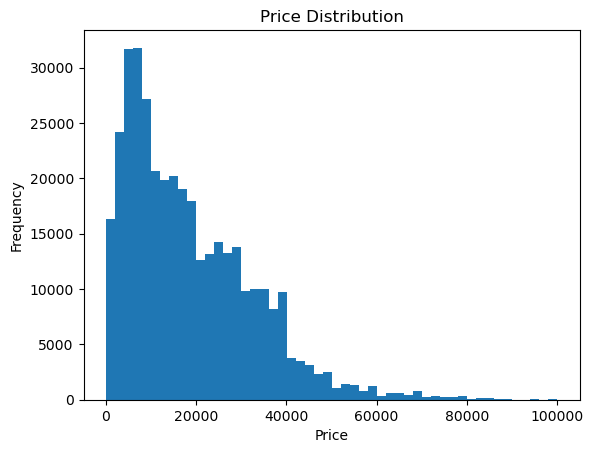

In [43]:
# clean out bad price values FIRST
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] > 100]
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] < 100000]

# THEN plot
import matplotlib.pyplot as plt

plt.hist(vehiclesdfc['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [44]:
# selecting features for modeling
df_model = vehiclesdfc[['price', 'year']]
df_model = df_model.dropna()

In [45]:
# X = features, y = target
X = df_model[['year']]
y = df_model['price']

In [46]:
from sklearn.model_selection import train_test_split

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

mse1 = mean_squared_error(y_test, y_pred1)
print("Linear Regression MSE:", mse1)

Linear Regression MSE: 173506510.83536038


In [48]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor(max_depth=5)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
print("Decision Tree MSE:", mse2)

Decision Tree MSE: 121691352.05825746


In [49]:
# Model 3: Ridge Regression
from sklearn.linear_model import Ridge

model3 = Ridge(alpha=1.0)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

mse3 = mean_squared_error(y_test, y_pred3)
print("Ridge MSE:", mse3)

Ridge MSE: 173506510.86493975
